# Project 7 — Intraday Volume-Profile Forecasting for VWAP Execution

**Goal.** Model how trading volume is distributed through the day, forecast tomorrow's profile, and use the forecast
to execute institutional orders against the **VWAP** benchmark better than naive schedules (TWAP, a static average profile).
Along the way: a **Gaussian-mixture** description of the intraday volume density, and **time-series clustering** of
daily profiles into "day types" (normal U-shape, close-heavy index/expiry days, open-heavy news days, FOMC days...).

**Data.** Massive (SIP consolidated) 1-minute bars for 30 liquid US stocks + SPY/QQQ, Jan-2022 → Sep-2026, aggregated
to 5-minute bins (78 regular-session bins) plus the 16:00 closing-print bar as a separate "close" bin.

| § | Content |
|---|---|
| 1 | Why the profile matters: VWAP, and the optimal VWAP schedule |
| 2 | Building the binned volume panel |
| 3 | Stylised facts: the U-shape, the growing close, cross-stock commonality |
| 4 | A Gaussian-mixture model of the intraday volume density |
| 5 | Clustering daily profiles into day types |
| 6 | Forecasting tomorrow's profile (static, calendar-conditional, cluster-conditional) |
| 7 | Execution simulation: TWAP vs static VWAP vs conditional vs dynamic (intraday-updating) VWAP |
| 8 | Strengths, weaknesses, extensions |

## 1. Why the profile matters
The day's VWAP is $\text{VWAP}=\sum_b p_b v_b/\sum_b v_b$, where $v_b$ is the market volume and $p_b$ the average price in bin $b$.
A broker executing a parent order of $Q$ shares as child orders $q_b$ (with $\sum q_b=Q$) gets an average price
$\bar p=\sum_b p_b q_b/Q$. The slippage against VWAP is
$$\bar p-\text{VWAP}=\sum_b p_b\Big(\frac{q_b}{Q}-\frac{v_b}{V}\Big).$$
If prices are a martingale and we ignore our own impact, the variance of this tracking error is minimised by setting
$q_b/Q$ equal to the **expected volume share** $E[v_b/V]$ (Konishi 2002). So a VWAP algorithm is, at heart, a
volume-*share* forecasting problem: the better we predict the shape, the smaller the tracking error. A second benefit:
trading in proportion to market volume keeps our participation rate constant, which minimises impact under the concave
(square-root) impact law.

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from IPython.display import display

from qdata import load_minute_bars, CACHE

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "JPM", "BAC", "XOM", "CVX",
           "UNH", "JNJ", "PFE", "MRK", "PG", "KO", "WMT", "HD", "V", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ORCL",
           "CRM", "T", "VZ", "CAT"]
START, END = "2022-01-01", "2026-09-11"
NB = 79                                      # 78 five-minute bins 09:30–15:55 + the 16:00 close bin

## 2. Building the binned panel
From 1-minute bars: bin $b=\lfloor(\text{minute}-570)/5\rfloor$ for 09:30–15:59, and bin 78 for the 16:00 bar (which
carries the closing-auction print). In each bin we keep the volume and a volume-weighted typical price
$(h+l+c)/3$, which serves as the bin's execution price. The result is cached (≈1 min to build).

In [2]:
cache = CACHE / "volume_bins_5m.parquet"
if cache.exists():
    VB = pd.read_parquet(cache)
else:
    t0, parts = time.time(), []
    for m0 in pd.date_range(START, END, freq="MS"):
        m = load_minute_bars(TICKERS, m0, m0 + pd.offsets.MonthEnd(0), regular_hours=False)
        if m.empty:
            continue
        m = m[(m.minute >= 570) & (m.minute <= 960)]
        m["bin"] = np.where(m.minute == 960, 78, (m.minute - 570) // 5)
        m["pv"] = m.volume * (m.high + m.low + m.close) / 3
        parts.append(m.groupby(["ticker", "date", "bin"], as_index=False)[["volume", "pv"]].sum())
    VB = pd.concat(parts, ignore_index=True)
    VB["px"] = VB.pv / VB.volume.replace(0, np.nan)
    VB = VB.drop(columns="pv")
    VB.to_parquet(cache)
    print(f"built in {time.time()-t0:.0f}s")

V = VB.pivot_table(index=["ticker", "date"], columns="bin", values="volume", aggfunc="sum").reindex(columns=range(NB)).fillna(0)
PX = VB.pivot_table(index=["ticker", "date"], columns="bin", values="px", aggfunc="last").reindex(columns=range(NB))
# half days (13:00 close) have no volume after bin 42; keep them aside
late = V.loc[:, 44:77].sum(1) / V.sum(1)
half = late < 0.02
print(f"{len(V):,} ticker-days, {V.index.get_level_values('date').nunique()} sessions; half days: "
      f"{sorted(set(V[half].index.get_level_values('date').date))}")
V, PX = V[~half], PX[~half]
S = V.div(V.sum(1), axis=0)                  # volume shares, each row sums to 1

37,574 ticker-days, 1177 sessions; half days: [datetime.date(2022, 11, 25), datetime.date(2023, 7, 3), datetime.date(2023, 11, 24), datetime.date(2024, 7, 3), datetime.date(2024, 11, 29), datetime.date(2024, 12, 24), datetime.date(2025, 7, 3), datetime.date(2025, 11, 28), datetime.date(2025, 12, 24)]


## 3. Stylised facts

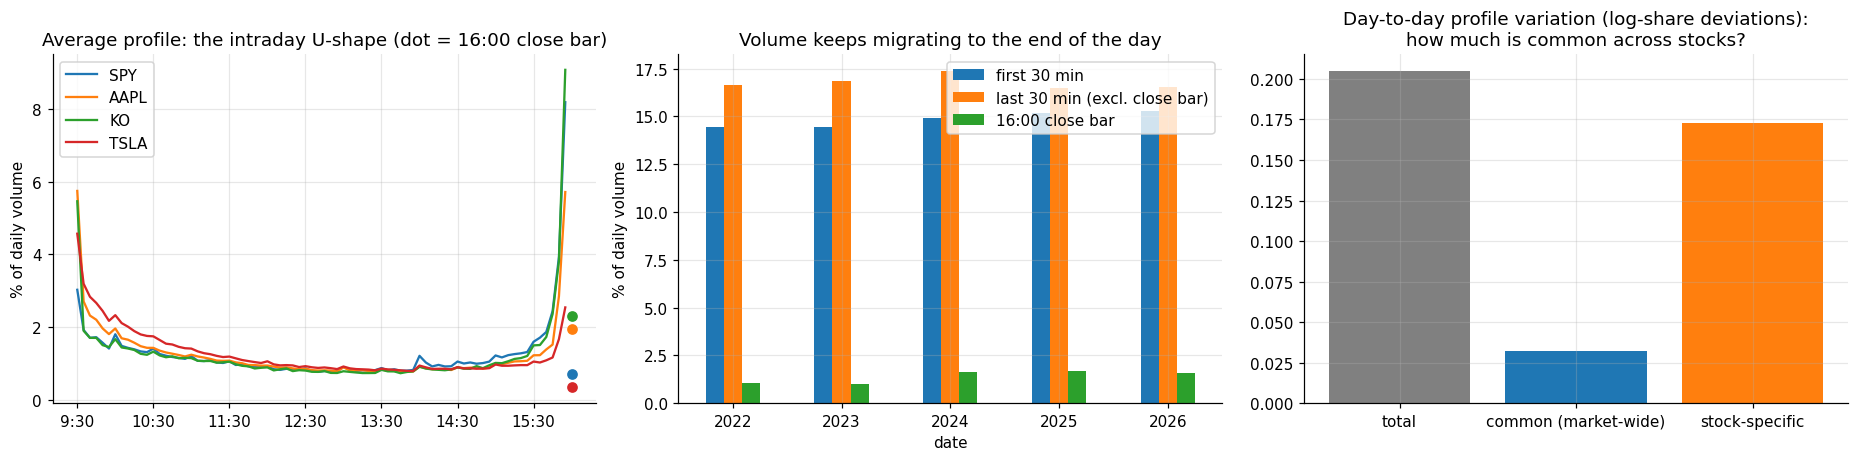

In [3]:
dates_all = S.index.get_level_values("date")
fig, axs = plt.subplots(1, 3, figsize=(17, 4.3))
x = np.arange(NB)
lab = [f"{(570 + 5*b)//60}:{(570 + 5*b) % 60:02d}" for b in range(78)] + ["close"]
for t, c in zip(["SPY", "AAPL", "KO", "TSLA"], plt.cm.tab10.colors):
    axs[0].plot(x[:78], S.loc[t].mean().values[:78] * 100, color=c, label=t)
    axs[0].plot([78], S.loc[t].mean().values[78] * 100, "o", color=c)
axs[0].set_xticks(range(0, NB, 12)); axs[0].set_xticklabels([lab[i] for i in range(0, NB, 12)])
axs[0].set_ylabel("% of daily volume"); axs[0].set_title("Average profile: the intraday U-shape (dot = 16:00 close bar)"); axs[0].legend()

yr = pd.Series(dates_all.year, index=S.index)
close_share = S[78].groupby(yr).mean() * 100
last30 = S.loc[:, 72:77].sum(1).groupby(yr).mean() * 100
first30 = S.loc[:, 0:5].sum(1).groupby(yr).mean() * 100
pd.DataFrame({"first 30 min": first30, "last 30 min (excl. close bar)": last30, "16:00 close bar": close_share}).plot.bar(ax=axs[1])
axs[1].set_ylabel("% of daily volume"); axs[1].set_title("Volume keeps migrating to the end of the day"); axs[1].tick_params(axis="x", rotation=0)

dev = np.log(S.clip(lower=1e-5)) - np.log(S.groupby(level="ticker").transform("mean").clip(lower=1e-5))
common = dev.groupby(level="date").mean()
spec_var = (dev - common.reindex(dates_all).values).var().mean()
axs[2].bar(["total", "common (market-wide)", "stock-specific"],
           [dev.var().mean(), common.var().mean(), spec_var], color=["grey", "tab:blue", "tab:orange"])
axs[2].set_title("Day-to-day profile variation (log-share deviations):\nhow much is common across stocks?")
plt.tight_layout(); plt.show()

* **The U-shape.** Volume is heavy at the open (price discovery after overnight news), light at lunch, and rises
  steeply into the close. The **last five-minute bin (15:55–16:00) is the largest of the day**, at 6–9 % of daily volume
  for single stocks. That's where closing-auction-related prints (MOC/LOC imbalance trading and, it appears, most of the cross
  itself) are time-stamped in this feed.
* **Data caveat: the 16:00 bar is small** (≈1–2 % of volume), well below the ~7–10 % of daily volume that exchanges
  report for closing auctions. The minute aggregates evidently don't isolate the auction print cleanly (trade condition codes
  decide which prints enter aggregate bars). We keep the 16:00 bar as its own bin but don't treat it as "the auction".
  A production VWAP engine would use exchange auction data.
* **End-of-day concentration is high and stable**: the last 30 minutes carry ~16–17 % of volume every year, and the small
  16:00 bar grows from ~1.0 % to ~1.6 %, consistent with the well-documented rise of benchmark-to-close (passive) trading.
* **Commonality is modest.** Only ~15 % of the day-to-day variance in profile *shape* is common to all stocks (macro news,
  FOMC at 14:00, index events). The rest is stock-specific noise and news. That's why the Białkowski–Darolles–Le Fol (2008)
  market + specific decomposition helps only a little for large caps, and why a single stock's daily profile is so noisy.

## 4. A Gaussian-mixture model of the intraday volume density
View the day's volume as a probability density over time-of-day $\tau\in[0,1)$. A mixture
$f(\tau)=\sum_{j=1}^J\pi_j\,\mathcal N(\tau;m_j,s_j^2)$ with a few components can describe the continuous part (the post-open
decay, midday trough, afternoon ramp) with $3J-1$ numbers. Three bins are **point masses** that we model separately: the opening
bin (which contains the opening cross), the final 15:55 bin (close-related imbalance trading) and the 16:00 bar. A Gaussian can't
reproduce a spike that sits in one 5-minute bin. We fit the mixture by weighted EM on the binned average profile, then polish it by least squares on the bin-integrated masses (EM on bin centres alone leaves visible wiggles). This compresses a 78-number profile
into a handful of interpretable parameters, which is useful for smoothing noisy single-stock profiles and for
comparing stocks.

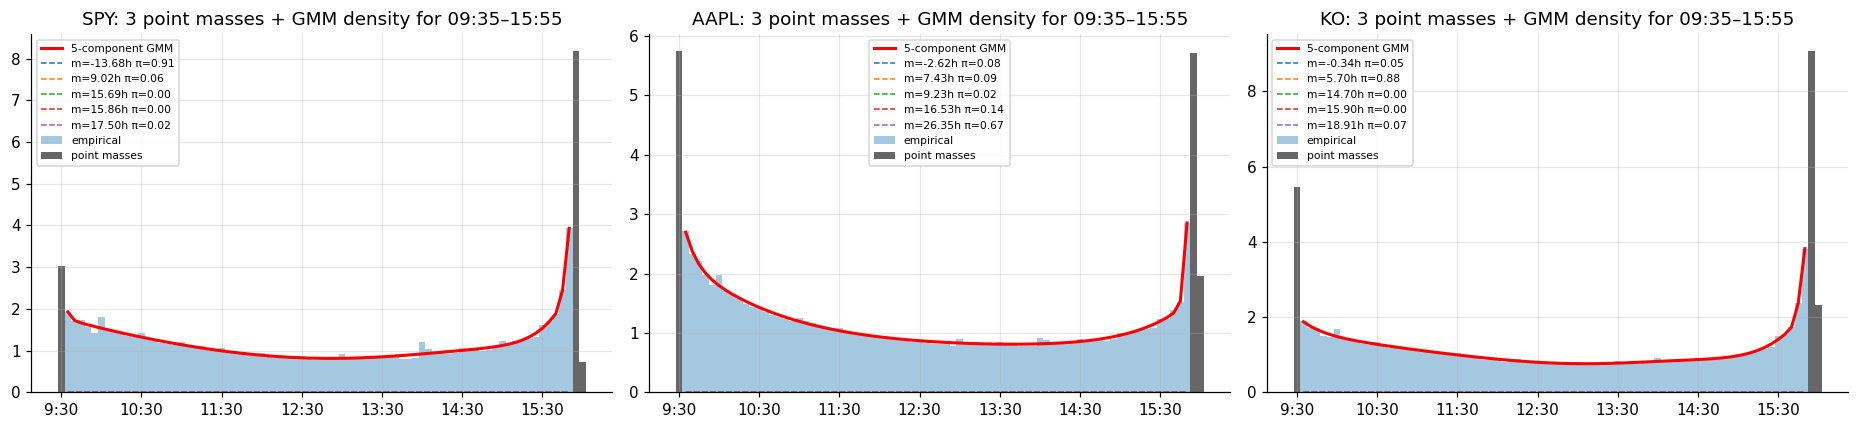

,open-bin mass,15:55 bin mass,16:00-bar mass,L1 error of GMM on continuous part (% of day's vol)
SPY,0.0303,0.0818,0.0072,1.6073
AAPL,0.0574,0.0571,0.0196,1.0710
KO,0.0546,0.0907,0.0231,1.1306


In [4]:
def weighted_gmm_1d(xc, w, J=4, iters=500, seed=0):
    """EM for a 1-D Gaussian mixture where observation i (bin centre xc_i) has weight w_i."""
    rng = np.random.default_rng(seed)
    w = w / w.sum()
    m = np.quantile(xc, np.sort(rng.uniform(0.02, 0.98, J))); s = np.full(J, 0.1); pi = np.full(J, 1 / J)
    for _ in range(iters):
        dens = pi * np.exp(-0.5 * ((xc[:, None] - m) / s) ** 2) / (s * np.sqrt(2 * np.pi))
        r = dens / dens.sum(1, keepdims=True)
        nk = (w[:, None] * r).sum(0)
        pi = nk
        m = (w[:, None] * r * xc[:, None]).sum(0) / nk
        s = np.sqrt((w[:, None] * r * (xc[:, None] - m) ** 2).sum(0) / nk).clip(0.01)
    return pi, m, s


def refine_gmm(pi, m, s, edges, target):
    """Polish the EM solution by least squares on the bin-integrated masses (what we actually care about)."""
    from scipy.optimize import least_squares
    J = len(pi)
    def unpack(z):
        p = np.exp(z[:J]); return p / p.sum(), z[J:2 * J], np.exp(z[2 * J:])
    def resid(z):
        return gmm_profile(*unpack(z), edges) - target
    z0 = np.r_[np.log(pi), m, np.log(s)]
    return unpack(least_squares(resid, z0, max_nfev=5000).x)


def gmm_profile(pi, m, s, edges):
    from scipy.stats import norm
    cdf = (pi * norm.cdf((edges[:, None] - m) / s)).sum(1)
    p = np.diff(cdf)
    return p / p.sum()


edges = np.linspace(0, 1, 79)
xc = (edges[:-1] + edges[1:]) / 2
fig, axs = plt.subplots(1, 3, figsize=(17, 4))
gmm_tab = {}
for ax, t in zip(axs, ["SPY", "AAPL", "KO"]):
    prof = S.loc[t].mean().values
    C_ = slice(1, 77)                                         # continuous part: 09:35–15:54
    mass = prof[C_].sum()
    pi, m, s = weighted_gmm_1d(xc[C_], prof[C_] / mass, J=5)          # EM for a starting point ...
    pi, m, s = refine_gmm(pi, m, s, edges[1:78], prof[C_] / mass)      # ... then fit the bin masses directly
    fit = gmm_profile(pi, m, s, edges[1:78]) * mass
    gmm_tab[t] = {"open-bin mass": prof[0], "15:55 bin mass": prof[77], "16:00-bar mass": prof[78],
                  "L1 error of GMM on continuous part (% of day's vol)": 50 * np.abs(fit - prof[C_]).sum()}
    ax.bar(x[C_], prof[C_] * 100, width=1, alpha=.4, label="empirical")
    ax.bar([0, 77, 78], prof[[0, 77, 78]] * 100, width=1, color="k", alpha=.6, label="point masses")
    ax.plot(x[C_], fit * 100, "r-", lw=2, label="5-component GMM")
    from scipy.stats import norm
    for j in np.argsort(m):
        comp = pi[j] * (norm.cdf((edges[2:78] - m[j]) / s[j]) - norm.cdf((edges[1:77] - m[j]) / s[j])) * mass
        ax.plot(x[C_], comp * 100, "--", lw=1, label=f"m={9.5 + m[j]*6.5:.2f}h π={pi[j]:.2f}")
    ax.set_xticks(range(0, 78, 12)); ax.set_xticklabels([lab[i] for i in range(0, 78, 12)])
    ax.set_title(f"{t}: 3 point masses + GMM density for 09:35–15:55"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
pd.DataFrame(gmm_tab).T

With the point masses handled separately, a handful of Gaussian components describe the rest: narrow ones for the decay after
the open, broad midday components, and one for the afternoon ramp. Compare the fit error in the
table (share of the day's volume misplaced) with the ~15 % day-to-day misallocation of even the best forecast in §6. The
parametric smoothing costs far less than the noise inherent in a single day's profile, so a GMM profile is a sensible,
compact prior for thinly traded stocks whose empirical profiles are too noisy to use raw.

## 5. Clustering daily profiles into day types
Days are not all alike. We cluster **shape deviations**: for each ticker-day, the log-ratio of its volume share to that
ticker's own trailing mean profile, aggregated to 13 half-hour blocks plus the close bin. We then reduce with PCA and fit a
Gaussian-mixture clustering (model-based time-series clustering). We fit on 2022–2023 and cross-tabulate the clusters
with calendar events *known in advance*:

* **OPEX**: monthly option expiry (3rd Friday); **quad witching**: Mar/Jun/Sep/Dec OPEX, which coincides with S&P index rebalancing;
* **month-end** (last session of the month): pension/index rebalancing flows at the close;
* **FOMC** announcement days (14:00 ET statement, 14:30 press conference);
* **CPI** release days (08:30 ET, before the open);
* Monday / Friday.

In [5]:
FOMC = pd.to_datetime([
    "2022-01-26", "2022-03-16", "2022-05-04", "2022-06-15", "2022-07-27", "2022-09-21", "2022-11-02", "2022-12-14",
    "2023-02-01", "2023-03-22", "2023-05-03", "2023-06-14", "2023-07-26", "2023-09-20", "2023-11-01", "2023-12-13",
    "2024-01-31", "2024-03-20", "2024-05-01", "2024-06-12", "2024-07-31", "2024-09-18", "2024-11-07", "2024-12-18",
    "2025-01-29", "2025-03-19", "2025-05-07", "2025-06-18", "2025-07-30", "2025-09-17", "2025-10-29", "2025-12-10",
    "2026-01-28", "2026-03-18", "2026-04-29", "2026-06-17", "2026-07-29", "2026-09-16"])
CPI = pd.to_datetime([
    "2022-01-12", "2022-02-10", "2022-03-10", "2022-04-12", "2022-05-11", "2022-06-10", "2022-07-13", "2022-08-10",
    "2022-09-13", "2022-10-13", "2022-11-10", "2022-12-13", "2023-01-12", "2023-02-14", "2023-03-14", "2023-04-12",
    "2023-05-10", "2023-06-13", "2023-07-12", "2023-08-10", "2023-09-13", "2023-10-12", "2023-11-14", "2023-12-12",
    "2024-01-11", "2024-02-13", "2024-03-12", "2024-04-10", "2024-05-15", "2024-06-12", "2024-07-11", "2024-08-14",
    "2024-09-11", "2024-10-10", "2024-11-13", "2024-12-11", "2025-01-15", "2025-02-12", "2025-03-12", "2025-04-10",
    "2025-05-13", "2025-06-11", "2025-07-15", "2025-08-12", "2025-09-11", "2025-10-24", "2025-12-18",
    "2026-01-13", "2026-02-11", "2026-03-11", "2026-04-10", "2026-05-12", "2026-06-10", "2026-07-14", "2026-08-12",
    "2026-09-11"])

sess = pd.DatetimeIndex(sorted(set(dates_all)))
cal = pd.DataFrame(index=sess)
third_fri = sess[(sess.dayofweek == 4) & (sess.day >= 15) & (sess.day <= 21)]
cal["opex"] = cal.index.isin(third_fri)
cal["quad_witching"] = cal.opex & cal.index.month.isin([3, 6, 9, 12])
cal["month_end"] = pd.Series(sess, index=sess).groupby(sess.to_period("M")).transform("max").eq(sess).values
cal["fomc"] = cal.index.isin(FOMC)
cal["cpi"] = cal.index.isin(CPI)
cal["monday"] = cal.index.dayofweek == 0
cal["friday"] = (cal.index.dayofweek == 4) & ~cal.opex
cal = cal.astype(int)

# half-hour blocks + close bin, as log-ratio to the ticker's trailing 60-session mean profile (strictly past data)
BLOCKS = [list(range(i, i + 6)) for i in range(0, 78, 6)] + [[78]]
SB = pd.concat({i: S[b].sum(1) for i, b in enumerate(BLOCKS)}, axis=1)
base = SB.groupby(level="ticker").transform(lambda c: c.rolling(60, min_periods=40).mean().shift(1))
D = np.log(SB.clip(lower=1e-5) / base.clip(lower=1e-5)).dropna()
Ddates = D.index.get_level_values("date")
TRAIN_END = pd.Timestamp("2023-12-31")

pca = PCA(5).fit(D[Ddates <= TRAIN_END])
Z = pca.transform(D)
bics = {k: GaussianMixture(k, covariance_type="full", random_state=0).fit(Z[Ddates <= TRAIN_END]).bic(Z[Ddates <= TRAIN_END])
        for k in range(2, 9)}
K = 5
gm = GaussianMixture(K, covariance_type="full", random_state=0, n_init=3).fit(Z[Ddates <= TRAIN_END])
lab_c = pd.Series(gm.predict(Z), index=D.index)
print("BIC by number of clusters:", {k: f"{v:,.0f}" for k, v in bics.items()}, f"→ using K={K} for interpretability")

BIC by number of clusters: {2: '82,845', 3: '81,430', 4: '81,028', 5: '81,360', 6: '81,213', 7: '81,387', 8: '81,559'} → using K=5 for interpretability


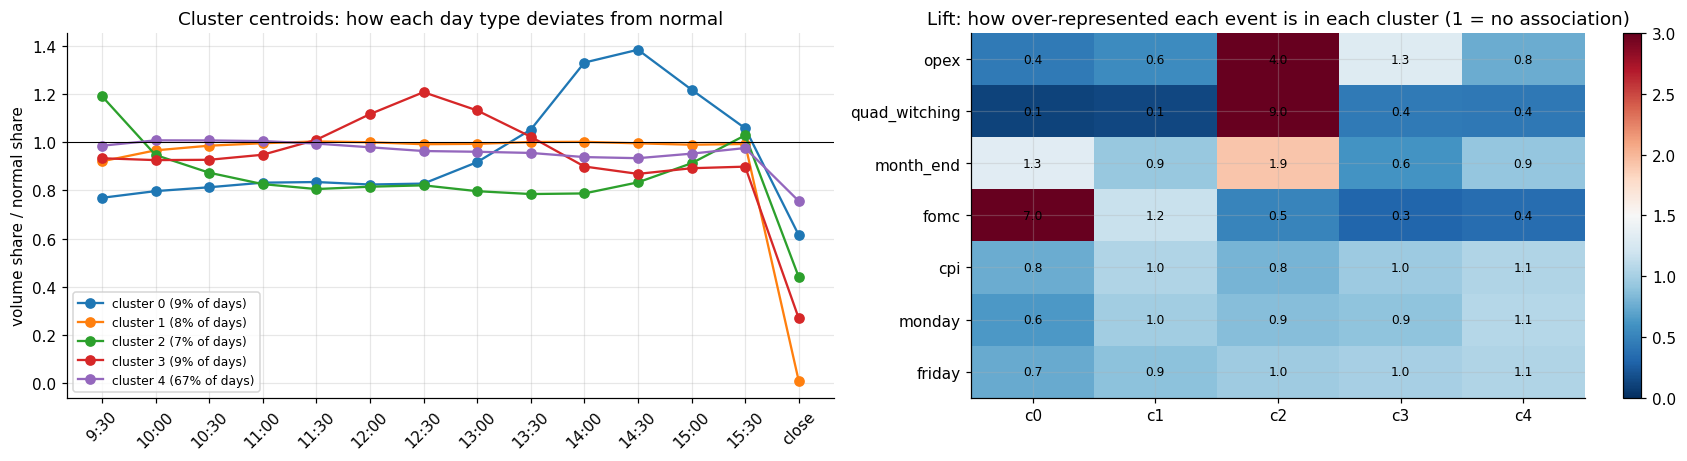

In [6]:
cent = D.groupby(lab_c.values).mean()
sizes = lab_c.value_counts(normalize=True).sort_index()
fig, axs = plt.subplots(1, 2, figsize=(16, 4.3))
blab = [lab[b[0]] for b in BLOCKS[:-1]] + ["close"]
for k in range(K):
    axs[0].plot(range(len(BLOCKS)), np.exp(cent.loc[k]).values, "o-", label=f"cluster {k} ({sizes[k]:.0%} of days)")
axs[0].axhline(1, color="k", lw=.7); axs[0].set_xticks(range(len(BLOCKS))); axs[0].set_xticklabels(blab, rotation=45)
axs[0].set_ylabel("volume share / normal share"); axs[0].set_title("Cluster centroids: how each day type deviates from normal"); axs[0].legend(fontsize=8)
ct = pd.DataFrame({k: cal.reindex(Ddates[lab_c.values == k]).mean() for k in range(K)})
ct["all days"] = cal.reindex(Ddates).mean()
lift = ct.div(ct["all days"], axis=0).drop(columns="all days")
im = axs[1].imshow(lift.values, cmap="RdBu_r", vmin=0, vmax=3, aspect="auto")
axs[1].set_yticks(range(len(lift))); axs[1].set_yticklabels(lift.index); axs[1].set_xticks(range(K)); axs[1].set_xticklabels([f"c{k}" for k in range(K)])
for i in range(lift.shape[0]):
    for j in range(K):
        axs[1].text(j, i, f"{lift.values[i, j]:.1f}", ha="center", va="center", fontsize=8)
axs[1].set_title("Lift: how over-represented each event is in each cluster (1 = no association)")
plt.colorbar(im, ax=axs[1]); plt.tight_layout(); plt.show()

**Reading the clusters.** The clustering is unsupervised, yet most clusters line up with known market mechanics (cluster
numbers come from the fitted mixture; check the plot for which is which):
* a large **"normal"** cluster (about two-thirds of days) with deviations close to 1 everywhere;
* an **FOMC** cluster: a volume bulge from 14:00 to 15:00 (statement at 14:00, press conference at 14:30), with FOMC days
  ~7× over-represented;
* an **expiry / index-rebalance** cluster: heavy open and heavy last half hour, light middle. Quad-witching days are ~9× and
  OPEX ~4× over-represented, month-ends ~2×;
* a **midday-bulge** cluster (news breaking during the session);
* a cluster defined almost entirely by a **missing 16:00 print**, which is a *data* day-type, not a market one. Clustering is a
  good way to discover such feed artefacts.

Because several of these day types are **known in advance** (the calendar), we can forecast which profile to expect.

## 6. Forecasting tomorrow's profile
Test period: 2024-01 → 2026-09, forecasts made with information up to the previous close. Models:

| Model | Forecast of $E[v_b/V]$ |
|---|---|
| **TWAP** | uniform over the 78 continuous bins (the close bin gets nothing), the naive schedule |
| **Static-20 / Static-60** | trailing 20- / 60-session mean share profile of the stock |
| **Calendar-adjusted** | Static-60 × multiplicative event factors (OPEX, quad, month-end, FOMC, CPI), estimated on 2022–23 |
| **Cluster-conditional** | Static-60 × $\sum_k \hat P(k\mid\text{calendar})\,e^{\bar d_k}$: a logistic classifier predicts cluster membership from the calendar, and centroids reshape the base profile |

Accuracy metric: **L1 misallocation** $\tfrac12\sum_b|\hat s_b-s_b|$ (the share of the day's volume we'd trade in the wrong bins).

In [7]:
base60 = S.groupby(level="ticker").transform(lambda c: c.rolling(60, min_periods=40).mean().shift(1))
base20 = S.groupby(level="ticker").transform(lambda c: c.rolling(20, min_periods=15).mean().shift(1))
twap = np.r_[np.ones(78) / 78, 0.0]

# expand block-level log-deviations back to bins
def block_to_bins(dvec):
    out = np.zeros(NB)
    for i, b in enumerate(BLOCKS):
        out[b] = dvec[i]
    return out

# (a) calendar factors: mean log deviation on event days minus on non-event days, per event (train period only)
Dtr = D[Ddates <= TRAIN_END]; caltr = cal.reindex(Dtr.index.get_level_values("date"))
EVENTS = ["opex", "quad_witching", "month_end", "fomc", "cpi"]
normal_mask = (caltr[EVENTS].sum(1) == 0).values
fac = {e: (Dtr[caltr[e].values == 1].mean() - Dtr[normal_mask].mean()).values for e in EVENTS}

# (b) cluster classifier from the calendar
clf = LogisticRegression(max_iter=2000, C=1.0).fit(caltr.values, lab_c[Ddates <= TRAIN_END].values)
cent_bins = np.array([block_to_bins(cent.loc[k].values) for k in range(K)])

test_idx = S.index[(S.index.get_level_values("date") > TRAIN_END)]
test_idx = test_idx[base60.loc[test_idx].notna().all(1).values & base20.loc[test_idx].notna().all(1).values]
ctest = cal.reindex(test_idx.get_level_values("date"))
fc = {}
fc["TWAP"] = np.tile(twap, (len(test_idx), 1))
fc["Static-20"] = base20.loc[test_idx].values
fc["Static-60"] = base60.loc[test_idx].values
adj = np.zeros((len(test_idx), NB))
for e in EVENTS:
    adj += ctest[e].values[:, None] * block_to_bins(fac[e])[None, :]
f = fc["Static-60"] * np.exp(adj); fc["Calendar-adjusted"] = f / f.sum(1, keepdims=True)
pk = clf.predict_proba(ctest.values)
mult = pk @ np.exp(cent_bins)
f = fc["Static-60"] * mult; fc["Cluster-conditional"] = f / f.sum(1, keepdims=True)

actual = S.loc[test_idx].values
l1 = pd.DataFrame({k: 0.5 * np.abs(v - actual).sum(1) for k, v in fc.items()}, index=test_idx)
l1_tab = pd.DataFrame({"all days": l1.mean()})
for e in ["quad_witching", "opex", "month_end", "fomc"]:
    l1_tab[e] = l1[ctest[e].values == 1].mean()
l1_tab["normal days"] = l1[(ctest[EVENTS].sum(1) == 0).values].mean()
print("Mean L1 misallocation (share of daily volume placed in the wrong bins), test 2024–2026")
l1_tab.style.format("{:.1%}").background_gradient(cmap="RdYlGn_r", axis=0)

Mean L1 misallocation (share of daily volume placed in the wrong bins), test 2024–2026


,all days,quad_witching,opex,month_end,fomc,normal days
TWAP,26.2%,38.9%,32.0%,27.9%,26.2%,25.9%
Static-20,15.6%,26.4%,20.9%,16.4%,17.8%,15.3%
Static-60,15.4%,26.2%,20.7%,16.1%,17.5%,15.0%
Calendar-adjusted,15.3%,25.5%,20.5%,15.7%,16.9%,15.0%
Cluster-conditional,15.3%,25.8%,20.5%,16.1%,16.3%,15.0%


What the table shows:
* **Any profile beats TWAP by a mile**: ~15 % vs ~26 % of volume misallocated. The U-shape is the first-order effect.
* A **longer window** (60 vs 20 sessions) helps slightly, because it averages away more day-specific noise.
* **Calendar / cluster conditioning helps where it should**: on FOMC days (17.5 % → ~16.3 %), quad witching and month-ends.
  It changes nothing on normal days. The average gain is small because event days are rare.
* Even the best forecast misplaces ~15 % of volume on a normal day. Most of the day-to-day profile variation is unpredictable
  from information available before the open, which is the motivation for updating *during* the day.

## 7. Execution simulation
**Set-up.** On each test ticker-day we buy $Q$ shares with a schedule $q_b=Q\hat s_b$, filled at the bin's
volume-weighted typical price. Slippage vs the realised day VWAP (all 79 bins) is in bp, positive = we paid more.
We ignore our own impact (the order is assumed small, ≈1 % ADV). The metric that matters is the **dispersion** of
slippage (tracking error), because a VWAP algorithm has no expected edge; its job is to *match* VWAP.

**Dynamic VWAP.** A static schedule ignores what the market is telling us during the day. After each bin we update
the forecast of the day's *remaining* volume. We take the prior (forecast share × ADV) and scale it by how busy the day has
been so far, shrunk toward 1 (exponent 0.5), then set the cumulative target to our estimate of the market's cumulative
fraction. This is a simple version of the dynamic models of Białkowski et al. (2008) and Humphery-Jenner (2011).

In [8]:
PXt = PX.loc[test_idx].values
Vt = V.loc[test_idx].values
PXt = pd.DataFrame(PXt).ffill(axis=1).bfill(axis=1).values       # empty bins → neighbouring price
vwap = (PXt * Vt).sum(1) / Vt.sum(1)
adv = V.sum(1).groupby(level="ticker").transform(lambda c: c.rolling(20, min_periods=15).mean().shift(1)).loc[test_idx].values


def slippage(sched):
    return ((PXt * sched).sum(1) / vwap - 1) * 1e4


def dynamic_schedule(prior, alpha=0.5):
    """Cumulative target = observed cum volume / (observed + expected remaining); trade the increment each bin."""
    n = len(prior)
    q = np.zeros_like(prior)
    cum_q = np.zeros(n)
    Pcum = np.cumsum(prior, axis=1)
    for b in range(NB):
        if b == NB - 1:
            q[:, b] = 1 - cum_q
            break
        # decide bin b's quantity using info up to b-1
        if b == 0:
            target = prior[:, 0]
        else:
            vobs = Vt[:, :b].sum(1)
            pc = np.clip(Pcum[:, b - 1], 1e-4, 1)
            ratio = np.clip(vobs / (adv * pc), 0.2, 5) ** alpha
            remaining = adv * (1 - pc) * ratio
            frac_done = vobs / (vobs + remaining)
            target = frac_done + prior[:, b] * (1 - frac_done) / np.clip(1 - pc, 1e-4, 1)
        target = np.clip(target, cum_q, 1)
        q[:, b] = target - cum_q
        cum_q = target
    return q


sched = {"TWAP": fc["TWAP"], "Static-60 VWAP": fc["Static-60"], "Cluster-conditional VWAP": fc["Cluster-conditional"],
         "Dynamic (cluster prior + intraday update)": dynamic_schedule(fc["Cluster-conditional"])}
slip = pd.DataFrame({k: slippage(v) for k, v in sched.items()}, index=test_idx)
res = pd.DataFrame({"mean (bp)": slip.mean(), "std = tracking error (bp)": slip.std(),
                    "mean |slippage| (bp)": slip.abs().mean(), "95th pct |slippage| (bp)": slip.abs().quantile(.95)})
res["TE reduction vs TWAP"] = 1 - res.iloc[:, 1] / res.iloc[0, 1]
res

,mean (bp),std = tracking error (bp),mean |slippage| (bp),95th pct |slippage| (bp),TE reduction vs TWAP
TWAP,0.3910,15.6492,9.2591,29.0967,0.0000
Static-60 VWAP,0.4019,12.6635,5.9598,20.5713,0.1908
Cluster-conditional VWAP,0.3829,12.7339,5.9886,20.4906,0.1863
Dynamic (cluster prior + intraday update),0.3511,13.3438,5.3496,18.7866,0.1473


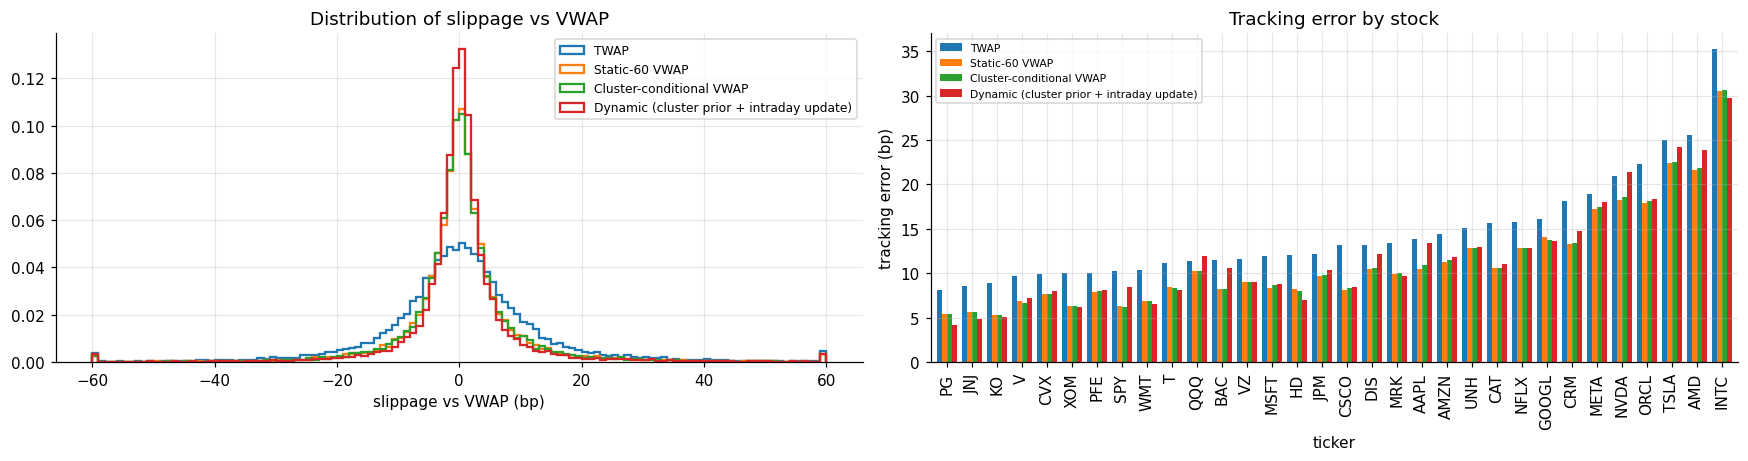

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4.3))
for k, c in zip(slip, plt.cm.tab10.colors):
    axs[0].hist(slip[k].clip(-60, 60), bins=120, histtype="step", lw=1.5, density=True, color=c, label=k)
axs[0].set_xlabel("slippage vs VWAP (bp)"); axs[0].set_title("Distribution of slippage vs VWAP"); axs[0].legend(fontsize=8)
te_t = slip.groupby(level="ticker").std()
te_t.sort_values("TWAP").plot.bar(ax=axs[1], width=.8)
axs[1].set_ylabel("tracking error (bp)"); axs[1].set_title("Tracking error by stock"); axs[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

**Results.**
* A profile-based schedule cuts the **typical** slippage vs VWAP by about a third compared with TWAP (mean |slippage| ≈ 9 → 6 bp)
  and the standard deviation by ~20 %.
* **Calendar/cluster conditioning** improves the profile on event days (§6), but the effect on overall tracking error is within
  noise. Event days are few, and slippage is dominated by the price path, not by the last few percent of shape accuracy.
* The **dynamic update** gives the lowest mean |slippage| and the smallest 95th-percentile error, but a *higher* standard
  deviation. Most days it adapts usefully to front- or back-loaded volume, but on a few days an early burst of volume makes it
  finish too early before a big afternoon move. The shrinkage exponent `alpha` trades these two off, and a production system
  would also cap how far ahead of the static schedule it may run.
* Tracking error is largest for high-volatility names (TSLA, NVDA, AMD) under every schedule, because it scales with
  intraday volatility × profile error. The value of a better profile is highest exactly there.

## 8. Strengths, weaknesses and extensions
**Strengths**
* The VWAP problem reduces cleanly to share forecasting, so improvements in the profile map directly into lower tracking error.
* GMM gives a compact, smooth, interpretable profile description; clustering discovers event-driven day types without labels.
* All forecasts are ex-ante (rolling windows, calendar known in advance) and the test period is strictly out of sample.

**Weaknesses / caveats**
* **No market impact**: fills at the bin's average price assume we are small. For large orders, our own trading moves both price
  and the VWAP itself, and a participation cap (e.g. ≤ 10 % of bin volume) would be needed.
* **Bin price ≈ typical price**: the true fill depends on spread-crossing vs passive fills within the bin.
* **Closing auction**: the 16:00 bar is a proxy for auction volume (SIP prints/aggregation conventions vary). A real algo sends MOC
  orders with their own imbalance-driven risk.
* **Earnings days** aren't in the calendar here (we'd need an earnings calendar), and they're among the most abnormal profiles.
* Survivorship: the universe is today's large caps.

**Extensions**
* The BDF common/specific decomposition with an ARMA/SETAR model for the specific component; functional data analysis (FPCA) of profiles.
* Joint forecasting of **daily total volume** and shape (the dynamic model's total-volume prior matters).
* Optimal execution with impact (Almgren–Chriss) using the forecast profile as a time-varying liquidity input.
* Futures: the same analysis for ES from Databento 1-minute bars, where the profile also depends on the European and Asian sessions.

**References.** Konishi, "Optimal slice of a VWAP trade", *J. Financial Markets* (2002); Białkowski, Darolles & Le Fol,
"Improving VWAP strategies: a dynamic volume approach", *J. Banking & Finance* (2008); Humphery-Jenner (2011);
Brownlees, Cipollini & Gallo, "Intra-daily volume modeling and prediction for algorithmic trading" (2011).